# B1. Nhập dữ liệu từ file CSV

In [2]:
import pandas as pd
df = pd.read_csv("data/email_classification.csv")
df

,id,label,subject,sender_domain,has_url,email_length,word_count,char_count,digit_count,uppercase_words,...,has_free,has_win,has_winner,has_click,has_offer,has_urgent,has_limited,has_buy,has_now,has_money
0,2685,0,Regarding Your Recent Inquiry,legitcompany.com,0,253,37,205,2,0,...,0,0,0,0,0,0,0,0,0,0
1,5857,0,Weekly Newsletter - Latest Updates,softwareupdates.com,0,290,44,231,0,1,...,0,0,0,0,0,0,0,0,0,0
2,2399,0,Important: Software Update Notification,softwareupdates.com,0,269,38,213,5,0,...,0,0,0,0,0,0,0,0,0,0
3,3244,0,Team Stand-up at 10 AM,customerservice.co,0,274,44,213,2,2,...,0,0,0,0,0,0,0,0,0,0
4,2844,0,Team Stand-up at 10 AM,customerservice.co,0,241,40,179,4,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,6397,0,Catching Up - How are you?,softwareupdates.com,0,282,45,221,0,1,...,0,0,0,0,0,0,0,0,0,0
9996,7470,0,Weekly Newsletter - Latest Updates,homemail.net,0,282,44,223,0,1,...,0,0,0,0,0,0,0,0,0,0
9997,9273,0,Feedback Request: Your Recent Purchase,projectmanagement.com,0,224,32,171,0,0,...,0,0,0,0,0,0,0,0,0,0
9998,3192,0,Photos from the Weekend Trip,billingcorp.com,0,255,39,199,5,0,...,0,0,0,0,0,0,0,0,0,0


##*Note: Đối với trường label: 1 = spam, 0 = not spam*

# B2. Tách dataset thành 2 phần: train và test

In [3]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

# B3. Với mỗi tập train và test, tách ra X và Y

In [4]:
import numpy as np

input_fields = [
    "has_url", "email_length", "word_count",
    "char_count", "digit_count", "uppercase_words",
    "exclamations", "avg_word_length", "punc_ratio",
    "has_noreply", "has_free", "has_win",
    "has_winner", "has_click", "has_offer",
    "has_urgent", "has_limited", "has_buy",
    "has_now", "has_money"
]

output_fields = [
    "label"
]

# validation
for field in input_fields:
    assert field in df.columns, f"Field {field} does not exist in df"

train_x = np.asarray(train_df[input_fields], dtype=float)
train_y = np.asarray(train_df[output_fields], dtype=float)

test_x = np.asarray(test_df[input_fields], dtype=float)
test_y = np.asarray(test_df[output_fields], dtype=float)

# B4. Tạo mô hình perceptron gồm cả cơ chế huấn luyện bằng luật học perceptron

In [5]:
import numpy as np

class Perceptron:
    def __init__(
        self,
        input_size: int,
        weights: np.ndarray | None = None,
        bias: float | None = None,
    ):
        if weights is None:
            self.weights = np.random.uniform(-0.05, 0.05, size=(input_size, 1))
        else:
            assert weights.shape == (input_size, 1), (
                f"input size is {input_size} but weights matrix has shape {weights.shape}"
            )
            self.weights = weights.astype(float)

        self.bias = 0.0 if bias is None else float(bias)

    def forward(self, x: np.ndarray) -> np.ndarray:
        # z: (N, input_size) @ (input_size, 1) -> (N, 1)
        z = x @ self.weights + self.bias
        return (z > 0).astype(int)

    def fit(
        self,
        x: np.ndarray,
        y: np.ndarray,
        learning_rate: float = 0.1,
        epochs: int = 100,
    ):
        assert y.shape == (x.shape[0], 1), (
            f"y has shape {y.shape}, expected {(x.shape[0], 1)}"
        )

        for _ in range(epochs):
            y_hat = self.forward(x)
            error = y - y_hat

            correct_count = np.count_nonzero(error == 0)
            total = error.shape[0]
            print(f"Accuracy: {correct_count/total: .2f}")
            if np.all(error == 0):
                break

            self.weights += learning_rate * (x.T @ error)
            self.bias += learning_rate * np.sum(error)

# B5. Huấn luyện mô hình

In [6]:
model = Perceptron(
    input_size=len(input_fields)
)

model.fit(train_x, train_y, epochs=200)

Accuracy:  0.85
Accuracy:  0.15
Accuracy:  0.85
Accuracy:  0.85
Accuracy:  0.85
Accuracy:  0.85
Accuracy:  0.85
Accuracy:  0.85
Accuracy:  0.85
Accuracy:  0.15
Accuracy:  0.85
Accuracy:  0.85
Accuracy:  0.85
Accuracy:  0.85
Accuracy:  0.85
Accuracy:  0.85
Accuracy:  0.85
Accuracy:  0.85
Accuracy:  0.15
Accuracy:  0.85
Accuracy:  0.85
Accuracy:  0.85
Accuracy:  0.85
Accuracy:  0.85
Accuracy:  0.85
Accuracy:  0.85
Accuracy:  0.85
Accuracy:  0.15
Accuracy:  0.85
Accuracy:  0.85
Accuracy:  0.85
Accuracy:  0.85
Accuracy:  0.85
Accuracy:  0.85
Accuracy:  0.85
Accuracy:  0.85
Accuracy:  0.15
Accuracy:  0.85
Accuracy:  0.85
Accuracy:  0.85
Accuracy:  0.85
Accuracy:  0.85
Accuracy:  0.85
Accuracy:  0.85
Accuracy:  0.85
Accuracy:  0.15
Accuracy:  0.85
Accuracy:  0.85
Accuracy:  0.85
Accuracy:  0.85
Accuracy:  0.85
Accuracy:  0.85
Accuracy:  0.85
Accuracy:  0.85
Accuracy:  0.15
Accuracy:  0.85
Accuracy:  0.85
Accuracy:  0.85
Accuracy:  0.85
Accuracy:  0.85
Accuracy:  0.85
Accuracy:  0.85
Accuracy

# B6. Kiểm thử mô hình

In [7]:
error = model.forward(test_x) - test_y

correct_count = np.count_nonzero(error == 0)
total = test_x.shape[0]
print(f"Total test samples: {total}")
print(f"Corrected predict samples: {correct_count}")
print(f"Accuracy: {correct_count / total: .2f}")

Total test samples: 2000
Corrected predict samples: 1682
Accuracy:  0.84


# B7. Đánh giá chi tiết (Confusion Matrix, Precision, Recall, F1-Score)

=== BÁO CÁO PHÂN LOẠI CHI TIẾT (CLASSIFICATION REPORT) ===
              precision    recall  f1-score   support

Not Spam (0)       0.84      1.00      0.91      1682
    Spam (1)       0.00      0.00      0.00       318

    accuracy                           0.84      2000
   macro avg       0.42      0.50      0.46      2000
weighted avg       0.71      0.84      0.77      2000

=== CHI TIẾT CONFUSION MATRIX ===
True Negative  (TN - Bắt đúng Non-Spam): 1682
False Positive (FP - Báo nhầm Spam)    : 0
False Negative (FN - Bỏ sót Spam)       : 318
True Positive  (TP - Bắt đúng Spam)     : 0


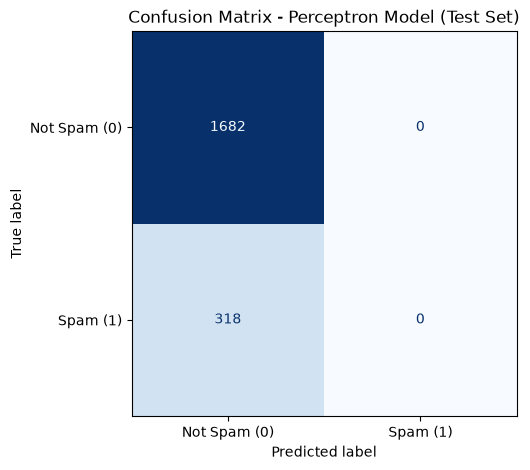

In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)

# Dự đoán nhãn kiểm thử
y_pred = model.forward(test_x).ravel()
y_true = test_y.ravel().astype(int)

# 1. Thống kê các chỉ số
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, zero_division=0)
rec = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)

print("=== BÁO CÁO PHÂN LOẠI CHI TIẾT (CLASSIFICATION REPORT) ===")
print(classification_report(y_true, y_pred, target_names=["Not Spam (0)", "Spam (1)"], zero_division=0))

# 2. Confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()
print("=== CHI TIẾT CONFUSION MATRIX ===")
print(f"True Negative  (TN - Bắt đúng Non-Spam): {tn}")
print(f"False Positive (FP - Báo nhầm Spam)    : {fp}")
print(f"False Negative (FN - Bỏ sót Spam)       : {fn}")
print(f"True Positive  (TP - Bắt đúng Spam)     : {tp}")

# 3. Vẽ Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Spam (0)", "Spam (1)"])
disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
plt.title("Confusion Matrix - Perceptron Model (Test Set)")
plt.grid(False)
plt.show()


# B8. Cải thiện mô hình với Feature Scaling (StandardScaler)

> Do đặc trưng có thang đo chênh lệch lớn (`char_count` ~ 200, trong khi các cờ `has_url` là 0 hoặc 1), Perceptron cập nhật batch dễ bị dao động. Chuẩn hóa đặc trưng giúp mô hình học chính xác cả 2 lớp.

Accuracy:  0.40
Accuracy:  0.92
Accuracy:  0.99
Accuracy:  0.99
Accuracy:  0.99
Accuracy:  1.00
=== BÁO CÁO PHÂN LOẠI SAU KHI CHUẨN HÓA (SCALED) ===
              precision    recall  f1-score   support

Not Spam (0)       1.00      1.00      1.00      1682
    Spam (1)       1.00      1.00      1.00       318

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



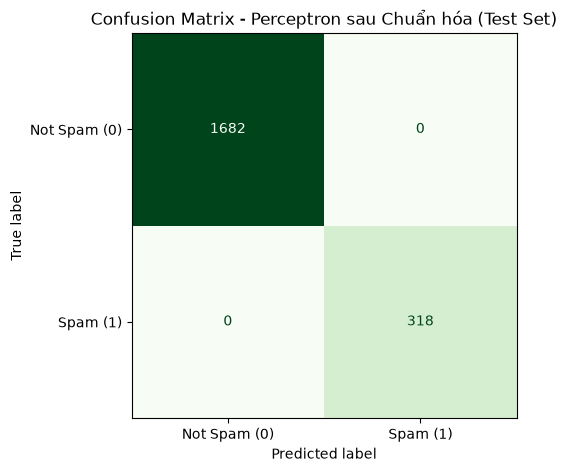

In [9]:
from sklearn.preprocessing import StandardScaler

# Chuẩn hóa đặc trưng
scaler = StandardScaler()
train_x_scaled = scaler.fit_transform(train_x)
test_x_scaled = scaler.transform(test_x)

# Huấn luyện mô hình Perceptron trên tập đã chuẩn hóa
model_scaled = Perceptron(input_size=len(input_fields))
model_scaled.fit(train_x_scaled, train_y, learning_rate=0.001, epochs=100)

# Dự đoán và vẽ Confusion Matrix sau chuẩn hóa
y_pred_scaled = model_scaled.forward(test_x_scaled).ravel()

print("=== BÁO CÁO PHÂN LOẠI SAU KHI CHUẨN HÓA (SCALED) ===")
print(classification_report(y_true, y_pred_scaled, target_names=["Not Spam (0)", "Spam (1)"], zero_division=0))

cm_scaled = confusion_matrix(y_true, y_pred_scaled, labels=[0, 1])
fig, ax = plt.subplots(figsize=(6, 5))
disp_scaled = ConfusionMatrixDisplay(confusion_matrix=cm_scaled, display_labels=["Not Spam (0)", "Spam (1)"])
disp_scaled.plot(ax=ax, cmap="Greens", colorbar=False, values_format="d")
plt.title("Confusion Matrix - Perceptron sau Chuẩn hóa (Test Set)")
plt.grid(False)
plt.show()
